<a href="https://colab.research.google.com/github/athreyyy/WebScraping_News_Website/blob/main/Web_Scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**No 1**

Scraping news website menggunakan request library dengan objek portal berita kompas. Untuk extract HTML sehingga mendapatkan h2 tag (headline) dan <a (URL) menggunakan library BeautifulSoup


In [ ]:
import requests
from bs4 import BeautifulSoup

#Requesting the website
URL='https://news.kompas.com'
response= requests.get(URL)
print ("The respose code is :  ",response)

#parase the HTML Document
soup=BeautifulSoup(response.content,'html.parser')
print(soup)

The respose code is :   <Response [200]>
<!DOCTYPE html>

<html lang="id">
<head>
<script>
    window.dataLayer = window.dataLayer || [];
    window.dataLayer.push({
    "title": "Berita Politik Hukum Nasional Terbaru Hari Ini - Kompas.com",
    "description": "Berita Terbaru Hari Ini, Menyajikan Kabar Terkini Indonesia dan Internasional Meliputi Berita Hukum, Politik, Nasional, Regional, Olahraga dan Sains",
    "keywords": "Berita Terkini, Berita Hari Ini, Breaking News, News Today, News, Hot News, Berita Internasional, Berita Dunia, Berita Nasional, Berita politik, Berita kriminal, Berita Ekonomi Bisnis, Berita Olahraga, Megapolitan, Berita Harian, Berita Akurat, Berita Tepercaya, Kompas",
    "content_category": "News",
    "content_subcategory": "",
    "canonical": "https:\/\/news.kompas.com",
    "url": "https:\/\/news.kompas.com\/"
});</script>
<!-- Google Tag Manager -->
<script>(function(w,d,s,l,i){w[l]=w[l]||[];w[l].push({'gtm.start':
new Date().getTime(),event:'gtm.js'});va

**No 2**

menggunakan "articles" sebagai list, sehingga data dapat dimasukkan kedalam database serentak.



In [ ]:
articles = []

for item in soup.select("div.articleItem"):
    h2 = item.select_one("h2.articleTitle")
    a_tag = item.select_one("a[href]")

    if h2 and a_tag:
        title = h2.text.strip()
        url = a_tag["href"]

        articles.append((title, url))

        print(title)
        print(url)

Uang Sudah Ada, Pemulihan untuk Korban Banjir Sumatera Diminta Dipercepat
https://nasional.kompas.com/read/2026/03/02/20185911/uang-sudah-ada-pemulihan-untuk-korban-banjir-sumatera-diminta-dipercepat
Divonis Bebas, 2 Terdakwa Kasus Dugaan Pembakaran Demo di Mapolda Jatim Bakal Tuntut Ganti Rugi?
https://surabaya.kompas.com/read/2026/03/02/201847078/divonis-bebas-2-terdakwa-kasus-dugaan-pembakaran-demo-di-mapolda-jatim
Pramono Ragu Gaji Nakes DKI Disebut Tak Naik Selama 10 Tahun: Masa Sih Enggak?
https://megapolitan.kompas.com/read/2026/03/02/20174821/pramono-ragu-gaji-nakes-dki-disebut-tak-naik-selama-10-tahun-masa-sih
MPBI DIY Petakan Kerawanan Pelanggaran THR: Sektor Ritel, Ojol, hingga PRT Jadi Perhatian
https://yogyakarta.kompas.com/read/2026/03/02/201706478/mpbi-diy-petakan-kerawanan-pelanggaran-thr-sektor-ritel-ojol-hingga-prt
Wali Kota Solo Minta Warga Tukar Uang Baru di Lembaga yang Ditunjuk BI, untuk Hindari Uang Palsu
https://regional.kompas.com/read/2026/03/02/201654878/wali

**No 3**

Import kedalam database menggunakan sqlite

In [ ]:
import sqlite3

conn = sqlite3.connect('kompas.db')
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS news_articles(
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    title TEXT,
    url TEXT
)
""")

cursor.executemany("""
INSERT INTO news_articles (title, url)
VALUES (?, ?)
""", articles
)
conn.commit()

print(f"Inserted {len(articles)} articles")

Inserted 59 articles


In [ ]:
cursor.execute("SELECT * FROM news_articles")
result=cursor.fetchall()
print(result)

[(1, 'Uang Sudah Ada, Pemulihan untuk Korban Banjir Sumatera Diminta Dipercepat', 'https://nasional.kompas.com/read/2026/03/02/20185911/uang-sudah-ada-pemulihan-untuk-korban-banjir-sumatera-diminta-dipercepat'), (2, 'Divonis Bebas, 2 Terdakwa Kasus Dugaan Pembakaran Demo di Mapolda Jatim Bakal Tuntut Ganti Rugi?', 'https://surabaya.kompas.com/read/2026/03/02/201847078/divonis-bebas-2-terdakwa-kasus-dugaan-pembakaran-demo-di-mapolda-jatim'), (3, 'Pramono Ragu Gaji Nakes DKI Disebut Tak Naik Selama 10 Tahun: Masa Sih Enggak?', 'https://megapolitan.kompas.com/read/2026/03/02/20174821/pramono-ragu-gaji-nakes-dki-disebut-tak-naik-selama-10-tahun-masa-sih'), (4, 'MPBI DIY Petakan Kerawanan Pelanggaran THR: Sektor Ritel, Ojol, hingga PRT Jadi Perhatian', 'https://yogyakarta.kompas.com/read/2026/03/02/201706478/mpbi-diy-petakan-kerawanan-pelanggaran-thr-sektor-ritel-ojol-hingga-prt'), (5, 'Wali Kota Solo Minta Warga Tukar Uang Baru di Lembaga yang Ditunjuk BI, untuk Hindari Uang Palsu', 'https

Hasil dari soal nomer 3 apabila dilihat melalui Dbeaver
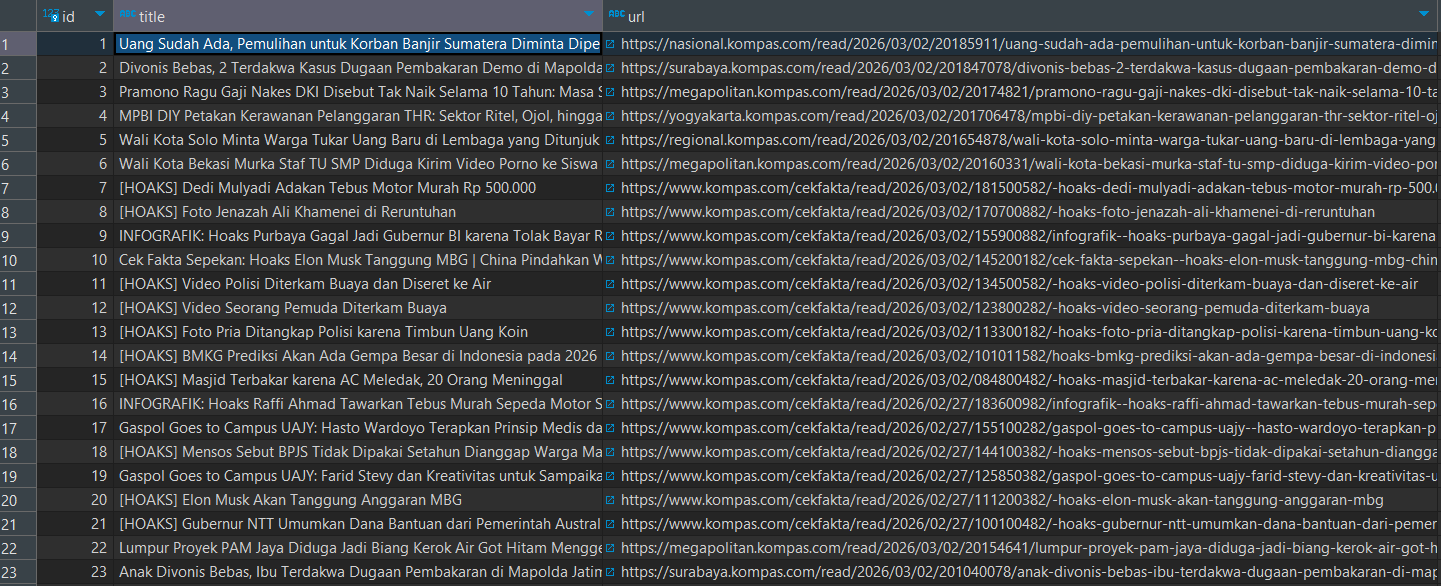